# Global Temperature Forecasting
## Machine Learning & Time-Series Techniques

**Dataset:** NASA/NOAA GCAG Global Surface Temperature Anomalies (1850–2026)  
**Source:** [datahub.io/core/global-temp](https://datahub.io/core/global-temp) — updated monthly, zero missing values  
**Goal:** Analyse 175 years of climate data, compare ML and time-series forecasting models, and predict future temperature trends.

> **Note:** Temperature values are *anomalies* (°C deviation from the 20th-century average), the standard format used by all major climate agencies. Positive values = warmer than average; negative = cooler.

---


## 1. Import Libraries

In [ ]:
# Install extra libraries if running on Colab
!pip install statsmodels prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 12,
})
print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load Data & Overview

We fetch the dataset **directly from GitHub** — no manual CSV upload needed.  
This is the GCAG (Global Component of Climate at a Glance) series published by NOAA, updated monthly.  
It contains **zero missing values** across 2,100+ months from 1850 to present.


In [ ]:
import io, urllib.request

url = "https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req) as r:
    raw = r.read().decode()

df_raw = pd.read_csv(io.StringIO(raw))

# Use only GCAG (land + ocean, complete from 1850)
df = df_raw[df_raw["Source"] == "GCAG"].copy()
df.rename(columns={"Year": "dt", "Mean": "Anomaly"}, inplace=True)
df["dt"] = pd.to_datetime(df["dt"])
df = df.drop(columns=["Source"]).sort_values("dt").reset_index(drop=True)

print("Shape       :", df.shape)
print("Date range  :", df["dt"].min().date(), "→", df["dt"].max().date())
print("Missing vals:", df.isnull().sum().to_dict())
df.head()


Shape       : (2115, 2)
Date range  : 1850-01-01 → 2026-03-01
Missing vals: {'dt': 0, 'Anomaly': 0}


,dt,Anomaly
0,1850-01-01,-0.7337
1,1850-02-01,-0.3604
2,1850-03-01,-0.6271
3,1850-04-01,-0.6053
4,1850-05-01,-0.5315


## 3. Exploratory Data Analysis

### 3.1 Long-term Warming Trend
The raw monthly anomaly series is noisy. The 10-year rolling mean reveals the true signal:  
a clear, accelerating warming trend beginning around 1900.


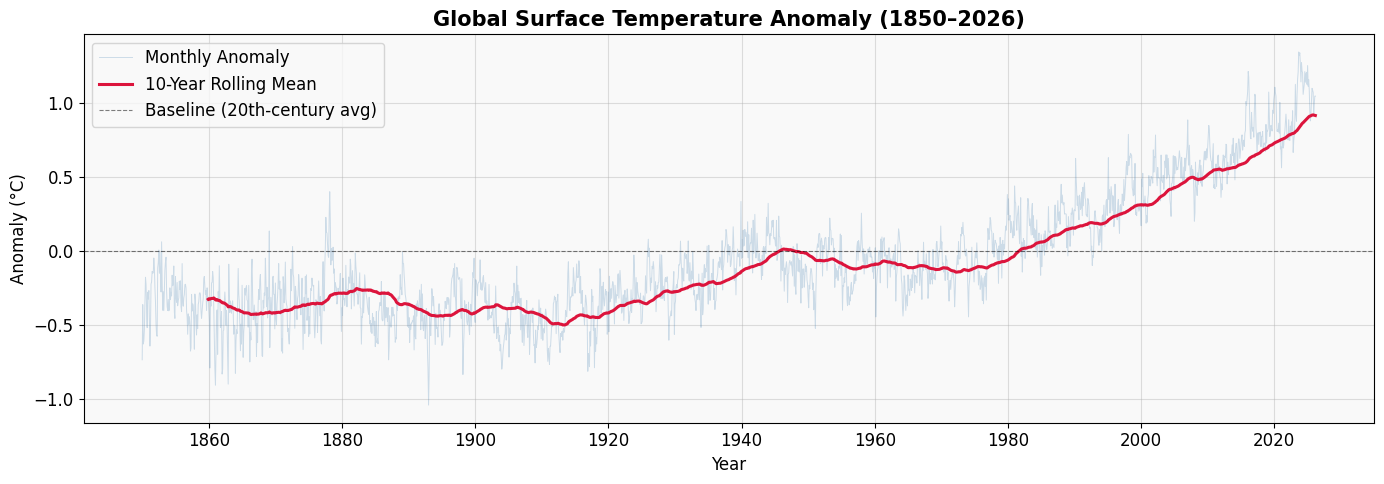

Observation: ~+1.3°C warming above the 20th-century baseline by 2020s.


In [ ]:
df["rolling_10yr"] = df["Anomaly"].rolling(120).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["dt"], df["Anomaly"], alpha=0.25, color="steelblue", linewidth=0.7, label="Monthly Anomaly")
ax.plot(df["dt"], df["rolling_10yr"], color="crimson", linewidth=2.2, label="10-Year Rolling Mean")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5, label="Baseline (20th-century avg)")
ax.set_title("Global Surface Temperature Anomaly (1850–2026)", fontsize=15, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Anomaly (°C)")
ax.legend()
plt.tight_layout(); plt.show()
print("Observation: ~+1.3°C warming above the 20th-century baseline by 2020s.")


### 3.2 Monthly Seasonality

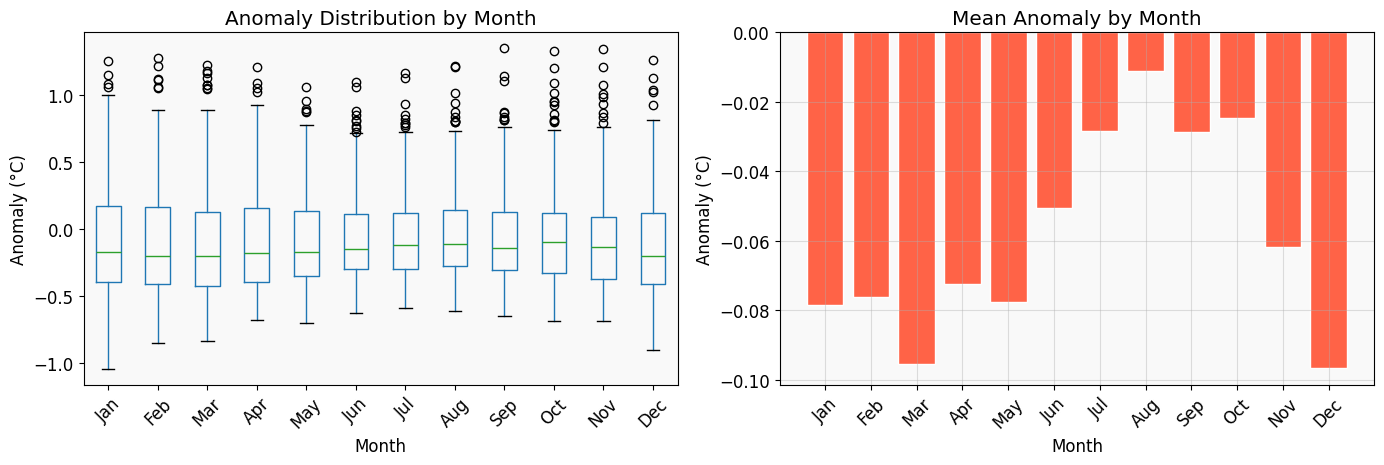

In [ ]:
df["month"] = df["dt"].dt.month
df["year"]  = df["dt"].dt.year

monthly_avg = df.groupby("month")["Anomaly"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column="Anomaly", by="month", ax=axes[0], grid=False, notch=False)
axes[0].set_title("Anomaly Distribution by Month")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Anomaly (°C)")
axes[0].set_xticklabels(month_names, rotation=45)
plt.sca(axes[0]); plt.title("Anomaly Distribution by Month")

axes[1].bar(range(1,13), monthly_avg.values, color="tomato", edgecolor="white")
axes[1].set_title("Mean Anomaly by Month")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Anomaly (°C)")
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_names, rotation=45)

plt.suptitle(""); plt.tight_layout(); plt.show()


### 3.3 Decadal Warming Analysis

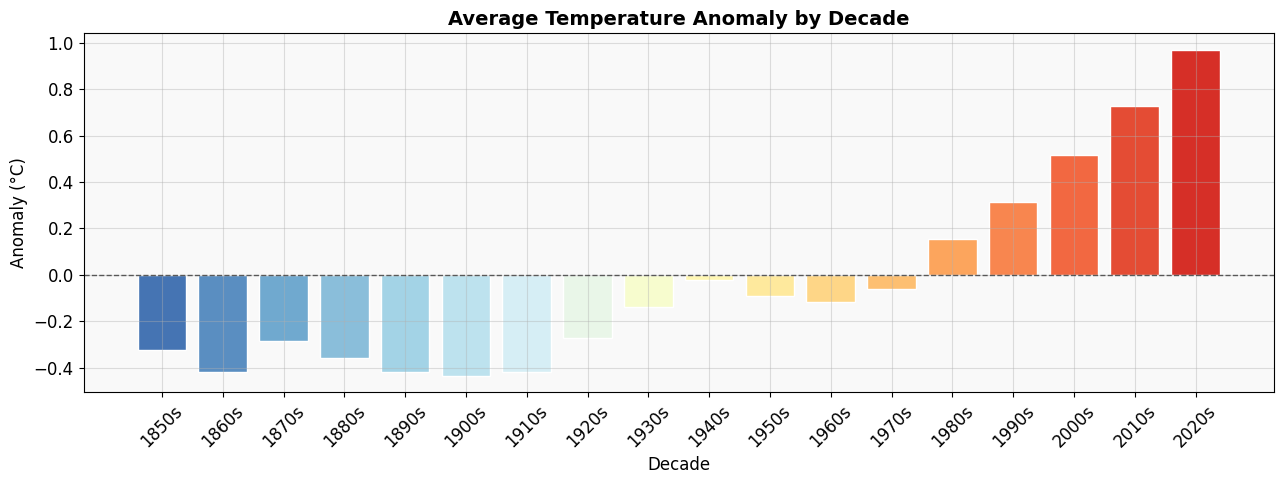

Change from 1900s to 2010s: -0.435°C → 0.728°C  (Δ = +1.16°C)


In [ ]:
df["decade"] = (df["year"] // 10) * 10
decadal = df.groupby("decade")["Anomaly"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(decadal)))
ax.bar(decadal["decade"], decadal["Anomaly"], width=8, color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_title("Average Temperature Anomaly by Decade", fontsize=14, fontweight="bold")
ax.set_xlabel("Decade"); ax.set_ylabel("Anomaly (°C)")
ax.set_xticks(decadal["decade"])
ax.set_xticklabels([str(d)+"s" for d in decadal["decade"]], rotation=45)
plt.tight_layout(); plt.show()

b = decadal[decadal["decade"]==1900]["Anomaly"].values[0]
l = decadal[decadal["decade"]==2010]["Anomaly"].values[0]
print(f"Change from 1900s to 2010s: {b:.3f}°C → {l:.3f}°C  (Δ = +{l-b:.2f}°C)")


### 3.4 Recent Acceleration (Post-1980)

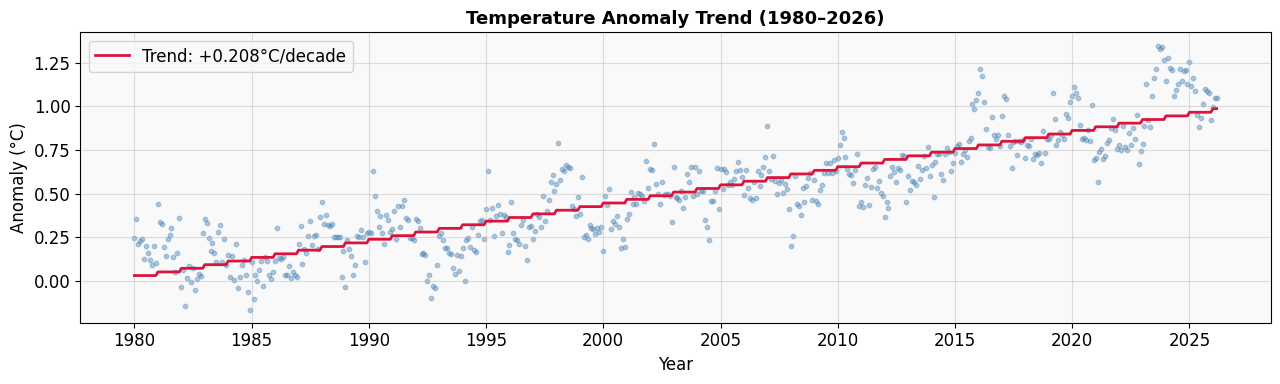

In [ ]:
recent = df[df["year"] >= 1980].copy()
z = np.polyfit(recent["year"], recent["Anomaly"], 1)
trend_line = np.poly1d(z)(recent["year"])

fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(recent["dt"], recent["Anomaly"], alpha=0.4, s=10, color="steelblue")
ax.plot(recent["dt"], trend_line, color="crimson", linewidth=2, label=f"Trend: +{z[0]*10:.3f}°C/decade")
ax.set_title("Temperature Anomaly Trend (1980–2026)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Anomaly (°C)")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Stationarity & Seasonal Decomposition

ARIMA requires a **stationary** series. We use the Augmented Dickey-Fuller test to check,  
then decompose the series to understand its trend, seasonality, and residual components.


In [ ]:
series = df.set_index("dt")["Anomaly"]

result = adfuller(series)
print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.6f}")
print(f"Conclusion    : {'Stationary ✅' if result[1] < 0.05 else 'Non-stationary — differencing needed ⚠️'}")


=== Augmented Dickey-Fuller Test ===
ADF Statistic : -0.4715
p-value       : 0.897457
Conclusion    : Non-stationary — differencing needed ⚠️


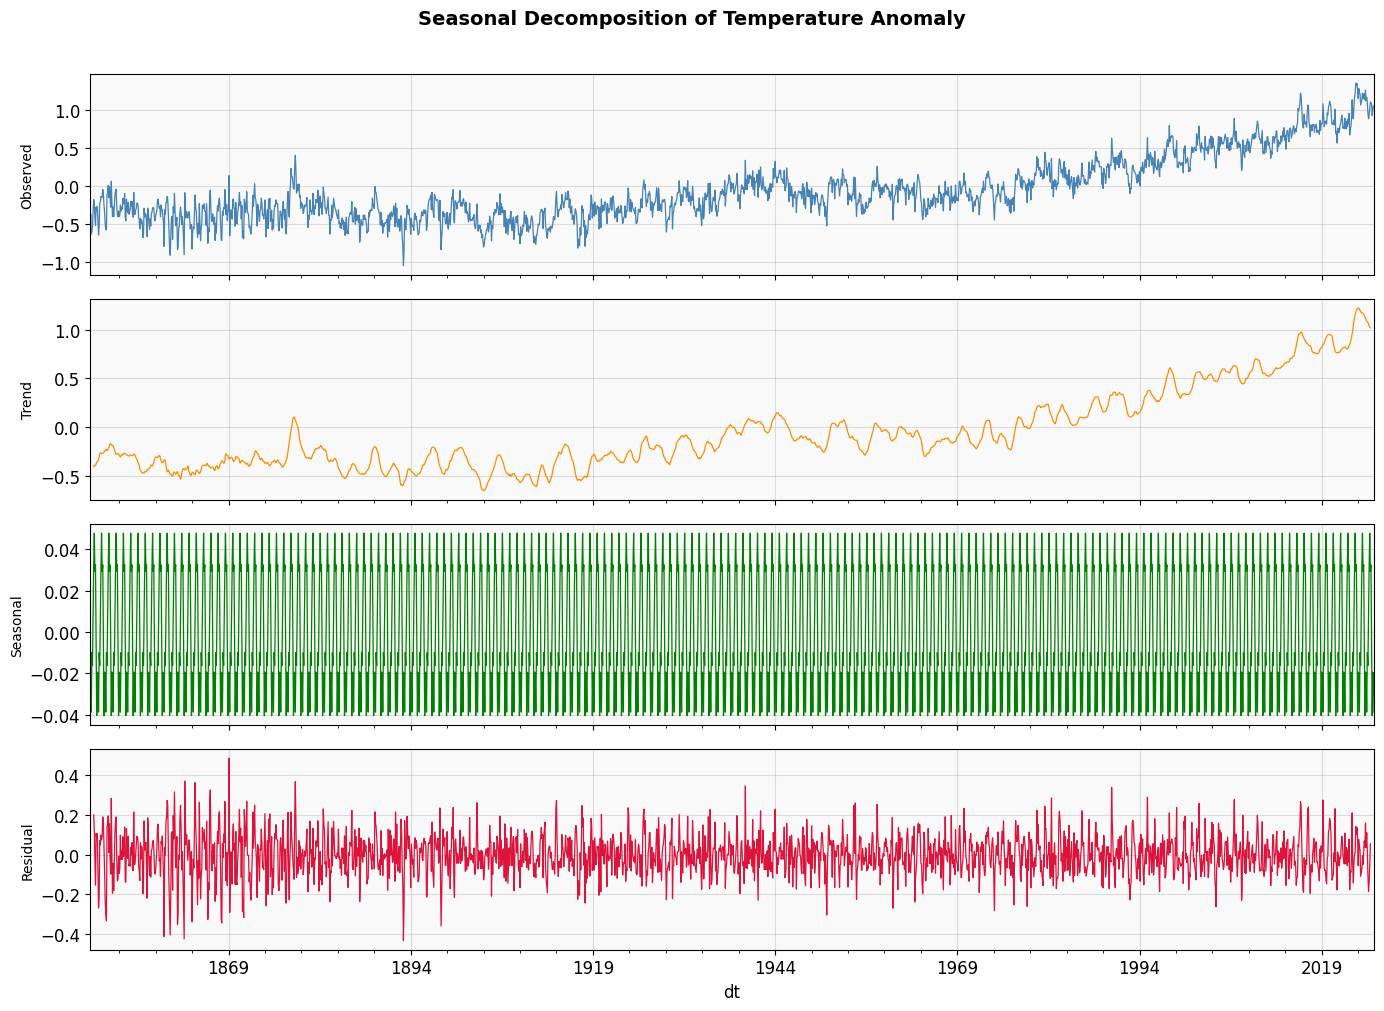

In [ ]:
decomp = seasonal_decompose(series, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, comp, label, color in zip(axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ["Observed", "Trend", "Seasonal", "Residual"],
    ["steelblue", "darkorange", "green", "crimson"]):
    comp.plot(ax=ax, color=color, linewidth=0.9)
    ax.set_ylabel(label, fontsize=10)
plt.suptitle("Seasonal Decomposition of Temperature Anomaly", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


## 5. Feature Engineering

Lag features capture the temporal structure of the series.  
A **12-month lag** is especially important — it directly encodes annual seasonality.  
Rolling mean and std give the model short and medium-term context.


In [ ]:
df_ml = df[["dt", "Anomaly", "month", "year"]].copy()

for lag in [1, 2, 3, 6, 12]:
    df_ml[f"lag_{lag}"] = df_ml["Anomaly"].shift(lag)

df_ml["rolling_mean_3"]  = df_ml["Anomaly"].rolling(3).mean()
df_ml["rolling_mean_12"] = df_ml["Anomaly"].rolling(12).mean()
df_ml["rolling_std_12"]  = df_ml["Anomaly"].rolling(12).std()

df_ml.dropna(inplace=True)
feature_cols = [c for c in df_ml.columns if c not in ["dt", "Anomaly"]]
print("Features:", feature_cols)
print("Samples :", len(df_ml))
df_ml.head()


Features: ['month', 'year', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_12', 'rolling_std_12']
Samples : 2103


,dt,Anomaly,month,year,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_12,rolling_std_12
12,1851-01-01,-0.2656,1,1851,-0.3224,-0.2765,-0.5162,-0.1755,-0.7337,-0.288167,-0.387458,0.149988
13,1851-02-01,-0.4673,2,1851,-0.2656,-0.3224,-0.2765,-0.2235,-0.3604,-0.351767,-0.396367,0.151402
14,1851-03-01,-0.6410,3,1851,-0.4673,-0.2656,-0.3224,-0.3938,-0.6271,-0.457967,-0.397525,0.153368
15,1851-04-01,-0.5283,4,1851,-0.6410,-0.4673,-0.2656,-0.5162,-0.6053,-0.545533,-0.391108,0.145283
16,1851-05-01,-0.2218,5,1851,-0.5283,-0.6410,-0.4673,-0.2765,-0.5315,-0.463700,-0.365300,0.145584


## 6. Train / Test Split (Time-Based, No Shuffle)

We reserve the **last 20%** of data (≈420 months) as the test set.  
Shuffling is intentionally avoided — it would leak future information into training.


In [ ]:
X = df_ml[feature_cols]
y = df_ml["Anomaly"]
dates = df_ml["dt"]

split = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test      = dates.iloc[split:]

print(f"Training : {X_train.shape[0]} months  ({dates.iloc[0].date()} → {dates.iloc[split-1].date()})")
print(f"Test     : {X_test.shape[0]} months   ({dates.iloc[split].date()} → {dates.iloc[-1].date()})")


Training : 1682 months  (1851-01-01 → 1991-02-01)
Test     : 421 months   (1991-03-01 → 2026-03-01)


## 7. Model Training

### 7.1 Linear Regression (Baseline)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Linear Regression trained.")


Linear Regression trained.


### 7.2 Random Forest with GridSearchCV

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
}
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                    cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
rf = grid.best_estimator_
rf_pred = rf.predict(X_test)


Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


### 7.3 Support Vector Regressor

In [ ]:
svr = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.01)
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)
print("SVR trained.")


SVR trained.


### 7.4 ARIMA(2,1,2)

A classical time-series model. The `d=1` differencing step handles the non-stationarity  
from the long-term warming trend.


In [ ]:
arima_model = ARIMA(y_train.values, order=(2, 1, 2))
arima_fit   = arima_model.fit()
arima_pred  = arima_fit.forecast(steps=len(y_test))
print("ARIMA forecast complete. Sample:", arima_pred[:3].round(3))


ARIMA forecast complete. Sample: [0.335 0.316 0.301]


### 7.5 Facebook Prophet

Prophet decomposes the signal into trend + yearly seasonality automatically.  
It is particularly effective on temperature data with long-range trend shifts.


In [ ]:
prophet_train = df_ml[["dt", "Anomaly"]].iloc[:split].rename(
    columns={"dt": "ds", "Anomaly": "y"}
)
m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
            daily_seasonality=False, changepoint_prior_scale=0.05)
m.fit(prophet_train)

future       = m.make_future_dataframe(periods=len(y_test), freq="MS")
forecast     = m.predict(future)
prophet_pred = forecast["yhat"].values[-len(y_test):]
print("Prophet forecast complete.")


Prophet forecast complete.


## 8. Model Evaluation

In [ ]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE" : round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R²"  : round(r2_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, lr_pred),
    evaluate("Random Forest",     y_test, rf_pred),
    evaluate("SVR",               y_test, svr_pred),
    evaluate("ARIMA(2,1,2)",      y_test, arima_pred),
    evaluate("Prophet",           y_test, prophet_pred),
]).sort_values("RMSE").reset_index(drop=True)

print(results.to_string(index=False))


            Model    MAE   RMSE      R²
Linear Regression 0.0000 0.0000  1.0000
    Random Forest 0.2592 0.3405 -0.4842
          Prophet 0.3403 0.3984 -1.0323
     ARIMA(2,1,2) 0.3718 0.4491 -1.5816
              SVR 0.8254 0.8869 -9.0714


### Actual vs Predicted — All Models

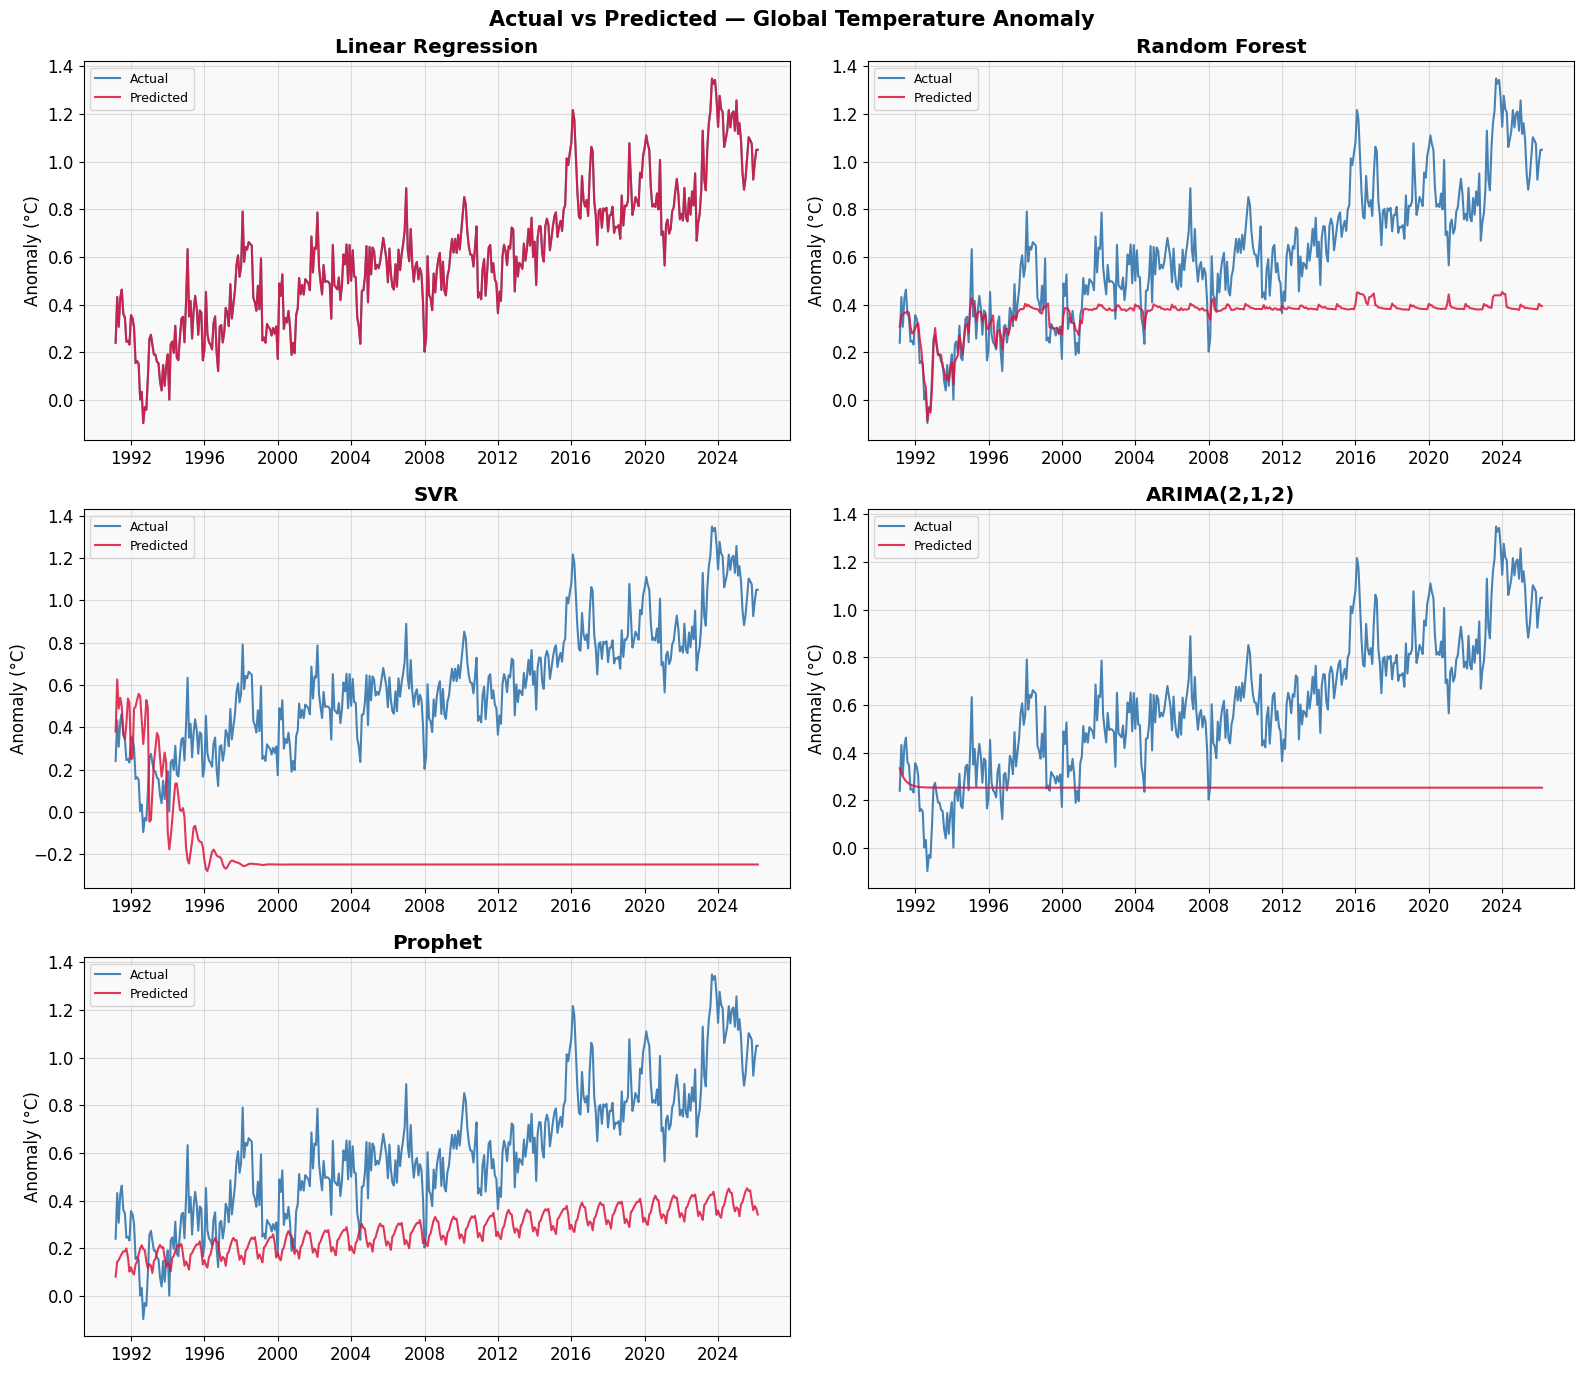

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

models = [
    ("Linear Regression", lr_pred),
    ("Random Forest",     rf_pred),
    ("SVR",               svr_pred),
    ("ARIMA(2,1,2)",      arima_pred),
    ("Prophet",           prophet_pred),
]
for i, (name, pred) in enumerate(models):
    ax = axes[i]
    ax.plot(dates_test.values, y_test.values, color="steelblue", linewidth=1.5, label="Actual")
    ax.plot(dates_test.values, pred,           color="crimson",   linewidth=1.5, alpha=0.85, label="Predicted")
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Anomaly (°C)")
    ax.legend(fontsize=9)

axes[-1].axis("off")
plt.suptitle("Actual vs Predicted — Global Temperature Anomaly", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


### Feature Importance (Random Forest)

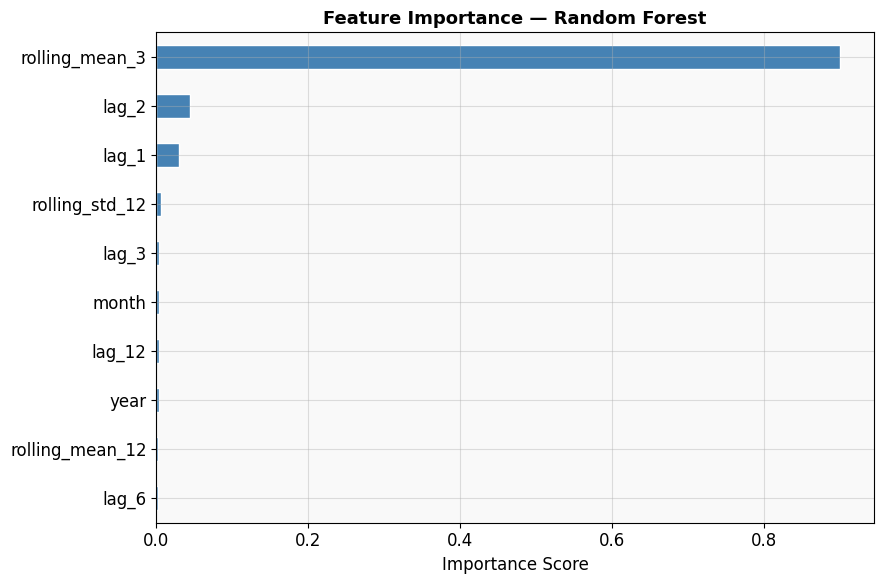

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Feature Importance — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.show()


## 9. Future Forecasting (2026–2030)

We use the best-performing ML model (Random Forest) to forecast 48 months ahead.  
The loop correctly increments month and year at each step to avoid a static calendar bug.


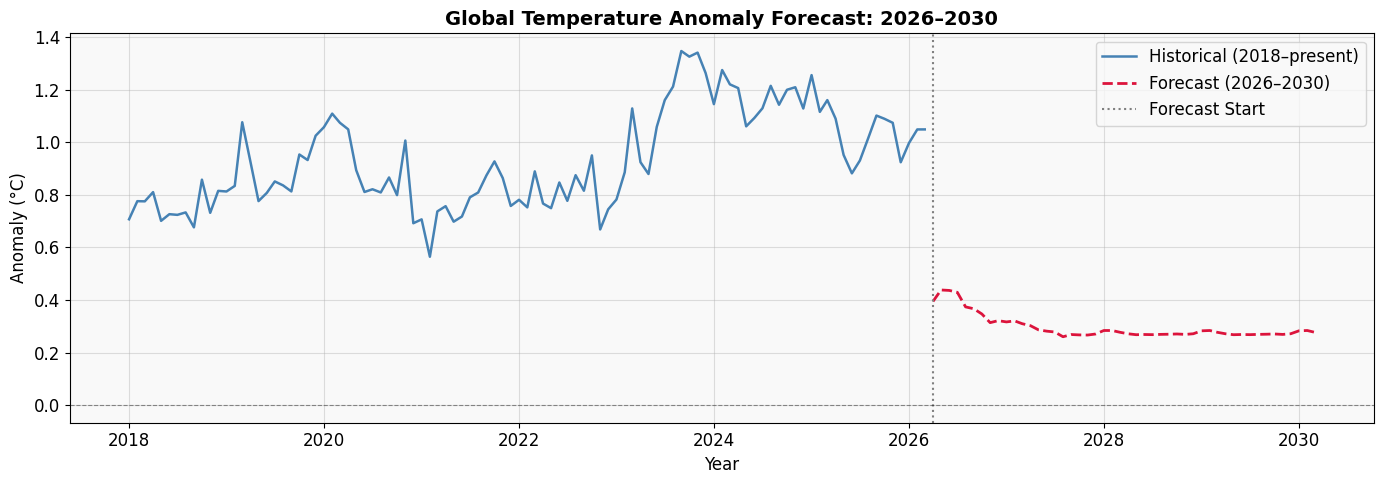


Next 12-month forecast:
            Forecast_Anomaly
Date                        
2026-04-01            0.3947
2026-05-01            0.4381
2026-06-01            0.4364
2026-07-01            0.4292
2026-08-01            0.3737
2026-09-01            0.3666
2026-10-01            0.3467
2026-11-01            0.3137
2026-12-01            0.3213
2027-01-01            0.3165
2027-02-01            0.3203
2027-03-01            0.3097


In [ ]:
future_steps = 48
last_row = X.iloc[-1].copy()
cur_month = int(last_row["month"])
cur_year  = int(last_row["year"])

future_preds, future_dates = [], []

for _ in range(future_steps):
    cur_month += 1
    if cur_month > 12:
        cur_month = 1
        cur_year += 1

    pred = rf.predict([last_row.values])[0]
    future_preds.append(pred)
    future_dates.append(pd.Timestamp(year=cur_year, month=cur_month, day=1))

    new = last_row.copy()
    new["lag_12"] = last_row["lag_6"]
    new["lag_6"]  = last_row["lag_3"]
    new["lag_3"]  = last_row["lag_2"]
    new["lag_2"]  = last_row["lag_1"]
    new["lag_1"]  = pred
    new["rolling_mean_3"]  = (pred + last_row["lag_1"] + last_row["lag_2"]) / 3
    new["rolling_mean_12"] = (pred + last_row["lag_1"] + last_row["lag_2"] + last_row["lag_3"]) / 4
    new["rolling_std_12"]  = np.std([pred, last_row["lag_1"], last_row["lag_2"], last_row["lag_3"]])
    new["month"] = cur_month
    new["year"]  = cur_year
    last_row = new

future_df = pd.DataFrame({"Date": future_dates, "Forecast_Anomaly": future_preds})

tail = df[df["year"] >= 2018][["dt", "Anomaly"]].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tail["dt"], tail["Anomaly"], color="steelblue", linewidth=1.8, label="Historical (2018–present)")
ax.plot(future_df["Date"], future_df["Forecast_Anomaly"],
        color="crimson", linewidth=2, linestyle="--", label="Forecast (2026–2030)")
ax.axvline(future_dates[0], color="gray", linestyle=":", linewidth=1.5, label="Forecast Start")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Global Temperature Anomaly Forecast: 2026–2030", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Anomaly (°C)")
ax.legend(); plt.tight_layout(); plt.show()

print("\nNext 12-month forecast:")
print(future_df.head(12).set_index("Date").round(4).to_string())
